In [0]:
storage_account_name = "jana60305219"
storage_account_key = "0GM7spdOovemizH7Y7FRNCvl/bLz5y0odTdC9mhp2Lm4/cxI9htWaDjHJU6iBEZlvhmmY8ymw3ic+AStT8nfqQ=="
spark.conf.set(
 f"fs.azure.account.key.{storage_account_name}.dfs.core.windows.net",
 storage_account_key
)

In [0]:
container_name = "raw"
file_name = "AmesHousing.csv"

csv_path = f"abfss://{container_name}@{storage_account_name}.dfs.core.windows.net/{file_name}"

df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(csv_path)

display(df.limit(5))


Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1,526301100,20,RL,141,31770,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112,TA,TA,CBlock,TA,Gd,Gd,BLQ,639,Unf,0,441,1080,GasA,Fa,Y,SBrkr,1656,0,0,1656,1,0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960,Fin,2,528,TA,TA,P,210,62,0,0,0,0,NA,NA,NA,0,5,2010,WD,Normal,215000
2,526350040,20,RH,80,11622,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0,TA,TA,CBlock,TA,TA,No,Rec,468,LwQ,144,270,882,GasA,TA,Y,SBrkr,896,0,0,896,0,0,1,0,2,1,TA,5,Typ,0,NA,Attchd,1961,Unf,1,730,TA,TA,Y,140,0,0,0,120,0,NA,MnPrv,NA,0,6,2010,WD,Normal,105000
3,526351010,20,RL,81,14267,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108,TA,TA,CBlock,TA,TA,No,ALQ,923,Unf,0,406,1329,GasA,TA,Y,SBrkr,1329,0,0,1329,0,0,1,1,3,1,Gd,6,Typ,0,NA,Attchd,1958,Unf,1,312,TA,TA,Y,393,36,0,0,0,0,NA,NA,Gar2,12500,6,2010,WD,Normal,172000
4,526353030,20,RL,93,11160,Pave,NA,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,None,0,Gd,TA,CBlock,TA,TA,No,ALQ,1065,Unf,0,1045,2110,GasA,Ex,Y,SBrkr,2110,0,0,2110,1,0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968,Fin,2,522,TA,TA,Y,0,0,0,0,0,0,NA,NA,NA,0,4,2010,WD,Normal,244000
5,527105010,60,RL,74,13830,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0,TA,TA,PConc,Gd,TA,No,GLQ,791,Unf,0,137,928,GasA,Gd,Y,SBrkr,928,701,0,1629,0,0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997,Fin,2,482,TA,TA,Y,212,34,0,0,0,0,NA,MnPrv,NA,0,3,2010,WD,Normal,189900


In [0]:
processed_container = "processed"
processed_path = f"abfss://{processed_container}@{storage_account_name}.dfs.core.windows.net/AmesHousing_cleaned"

df.write.format("parquet").mode("overwrite").save(processed_path)


In [0]:
processed_path = f"abfss://processed@{storage_account_name}.dfs.core.windows.net/AmesHousing_cleaned"
df_processed = spark.read.parquet(processed_path)
display(df_processed.limit(5))


Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1,526301100,20,RL,141,31770,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112,TA,TA,CBlock,TA,Gd,Gd,BLQ,639,Unf,0,441,1080,GasA,Fa,Y,SBrkr,1656,0,0,1656,1,0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960,Fin,2,528,TA,TA,P,210,62,0,0,0,0,NA,NA,NA,0,5,2010,WD,Normal,215000
2,526350040,20,RH,80,11622,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0,TA,TA,CBlock,TA,TA,No,Rec,468,LwQ,144,270,882,GasA,TA,Y,SBrkr,896,0,0,896,0,0,1,0,2,1,TA,5,Typ,0,NA,Attchd,1961,Unf,1,730,TA,TA,Y,140,0,0,0,120,0,NA,MnPrv,NA,0,6,2010,WD,Normal,105000
3,526351010,20,RL,81,14267,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108,TA,TA,CBlock,TA,TA,No,ALQ,923,Unf,0,406,1329,GasA,TA,Y,SBrkr,1329,0,0,1329,0,0,1,1,3,1,Gd,6,Typ,0,NA,Attchd,1958,Unf,1,312,TA,TA,Y,393,36,0,0,0,0,NA,NA,Gar2,12500,6,2010,WD,Normal,172000
4,526353030,20,RL,93,11160,Pave,NA,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,None,0,Gd,TA,CBlock,TA,TA,No,ALQ,1065,Unf,0,1045,2110,GasA,Ex,Y,SBrkr,2110,0,0,2110,1,0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968,Fin,2,522,TA,TA,Y,0,0,0,0,0,0,NA,NA,NA,0,4,2010,WD,Normal,244000
5,527105010,60,RL,74,13830,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0,TA,TA,PConc,Gd,TA,No,GLQ,791,Unf,0,137,928,GasA,Gd,Y,SBrkr,928,701,0,1629,0,0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997,Fin,2,482,TA,TA,Y,212,34,0,0,0,0,NA,MnPrv,NA,0,3,2010,WD,Normal,189900


In [0]:
processed_path = f"abfss://processed@{storage_account_name}.dfs.core.windows.net/AmesHousing_cleaned"

df_processed = spark.read.parquet(processed_path)
display(df_processed.limit(5))


Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1,526301100,20,RL,141,31770,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112,TA,TA,CBlock,TA,Gd,Gd,BLQ,639,Unf,0,441,1080,GasA,Fa,Y,SBrkr,1656,0,0,1656,1,0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960,Fin,2,528,TA,TA,P,210,62,0,0,0,0,NA,NA,NA,0,5,2010,WD,Normal,215000
2,526350040,20,RH,80,11622,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0,TA,TA,CBlock,TA,TA,No,Rec,468,LwQ,144,270,882,GasA,TA,Y,SBrkr,896,0,0,896,0,0,1,0,2,1,TA,5,Typ,0,NA,Attchd,1961,Unf,1,730,TA,TA,Y,140,0,0,0,120,0,NA,MnPrv,NA,0,6,2010,WD,Normal,105000
3,526351010,20,RL,81,14267,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108,TA,TA,CBlock,TA,TA,No,ALQ,923,Unf,0,406,1329,GasA,TA,Y,SBrkr,1329,0,0,1329,0,0,1,1,3,1,Gd,6,Typ,0,NA,Attchd,1958,Unf,1,312,TA,TA,Y,393,36,0,0,0,0,NA,NA,Gar2,12500,6,2010,WD,Normal,172000
4,526353030,20,RL,93,11160,Pave,NA,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,None,0,Gd,TA,CBlock,TA,TA,No,ALQ,1065,Unf,0,1045,2110,GasA,Ex,Y,SBrkr,2110,0,0,2110,1,0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968,Fin,2,522,TA,TA,Y,0,0,0,0,0,0,NA,NA,NA,0,4,2010,WD,Normal,244000
5,527105010,60,RL,74,13830,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0,TA,TA,PConc,Gd,TA,No,GLQ,791,Unf,0,137,928,GasA,Gd,Y,SBrkr,928,701,0,1629,0,0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997,Fin,2,482,TA,TA,Y,212,34,0,0,0,0,NA,MnPrv,NA,0,3,2010,WD,Normal,189900


In [0]:
print(df_processed.columns)


['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood Deck 

In [0]:
from pyspark.sql.functions import col


for c in df_processed.columns:
    df_processed = df_processed.withColumnRenamed(c, c.replace(" ", "_"))

print(df_processed.columns[:20])  # check first 20


['Order', 'PID', 'MS_SubClass', 'MS_Zoning', 'Lot_Frontage', 'Lot_Area', 'Street', 'Alley', 'Lot_Shape', 'Land_Contour', 'Utilities', 'Lot_Config', 'Land_Slope', 'Neighborhood', 'Condition_1', 'Condition_2', 'Bldg_Type', 'House_Style', 'Overall_Qual', 'Overall_Cond']


In [0]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["Gr_Liv_Area", "Garage_Area", "Total_Bsmt_SF", "Year_Built"],
    outputCol="numerical_features"
)

df_num = assembler.transform(df_processed)
display(df_num.select("numerical_features").limit(5))


numerical_features
"Map(vectorType -> dense, length -> 4, values -> List(1656.0, 528.0, 1080.0, 1960.0))"
"Map(vectorType -> dense, length -> 4, values -> List(896.0, 730.0, 882.0, 1961.0))"
"Map(vectorType -> dense, length -> 4, values -> List(1329.0, 312.0, 1329.0, 1958.0))"
"Map(vectorType -> dense, length -> 4, values -> List(2110.0, 522.0, 2110.0, 1968.0))"
"Map(vectorType -> dense, length -> 4, values -> List(1629.0, 482.0, 928.0, 1997.0))"


In [0]:
assembler = VectorAssembler(
    inputCols=["Gr_Liv_Area", "Garage_Area", "Total_Bsmt_SF", "Year_Built"],
    outputCol="numerical_features",
    handleInvalid="keep"
)

df_num = assembler.transform(df_processed)


In [0]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(inputCol="numerical_features", outputCol="numerical_scaled")
df_scaled = scaler.fit(df_num).transform(df_num)

display(df_scaled.select("numerical_scaled").limit(5))


numerical_scaled
"Map(vectorType -> dense, length -> 4, values -> List(3.275906796181876, NaN, NaN, 64.80332716206445))"
"Map(vectorType -> dense, length -> 4, values -> List(1.7724713100114498, NaN, NaN, 64.8363900840859))"
"Map(vectorType -> dense, length -> 4, values -> List(2.6290338962111797, NaN, NaN, 64.73720131802152))"
"Map(vectorType -> dense, length -> 4, values -> List(4.1740116787099995, NaN, NaN, 65.06783053823614))"
"Map(vectorType -> dense, length -> 4, values -> List(3.2224952723310847, NaN, NaN, 66.02665527685852))"


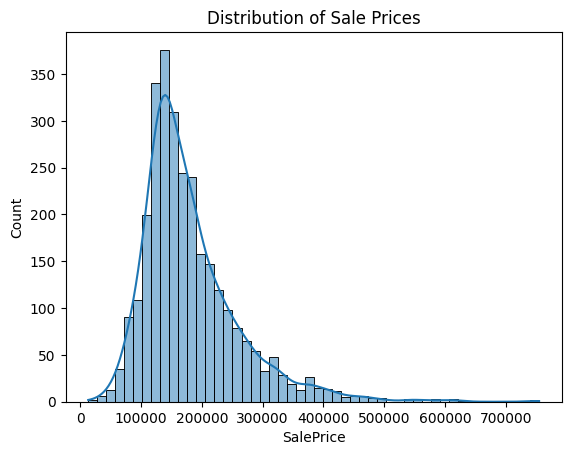

In [0]:
pdf = df_processed.toPandas()
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(pdf["SalePrice"], bins=50, kde=True)
plt.title("Distribution of Sale Prices")
plt.show()


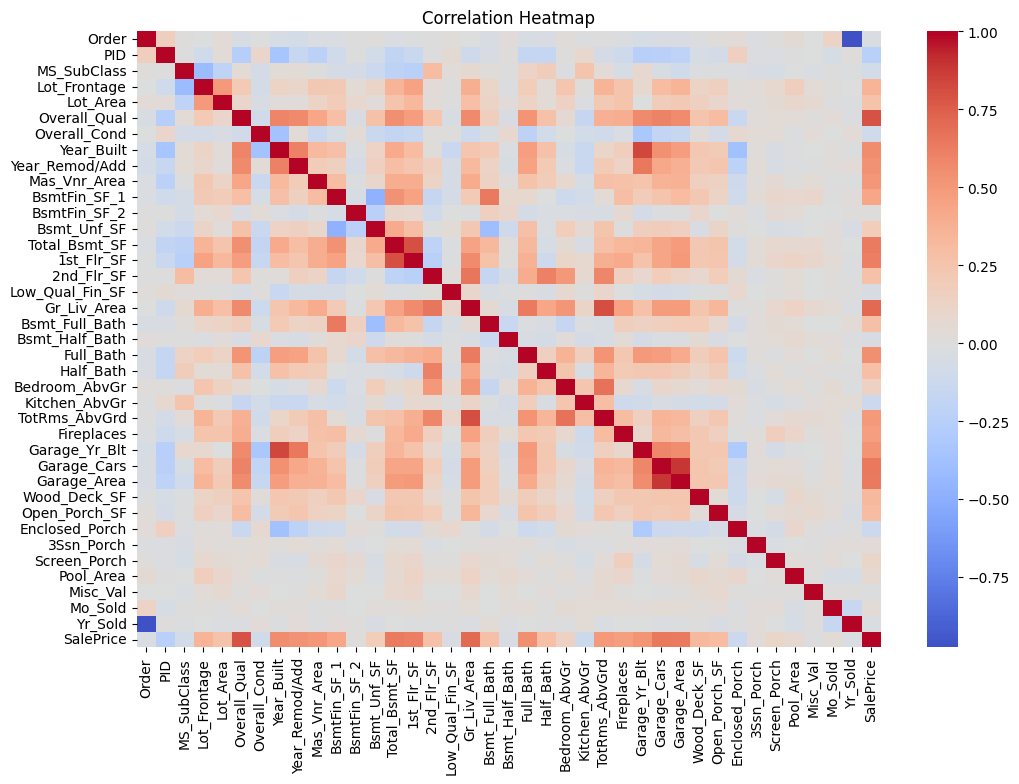

SalePrice         1.000000
Overall_Qual      0.799262
Gr_Liv_Area       0.706780
Garage_Cars       0.647877
Garage_Area       0.640401
Total_Bsmt_SF     0.632280
1st_Flr_SF        0.621676
Year_Built        0.558426
Full_Bath         0.545604
Year_Remod/Add    0.532974
Name: SalePrice, dtype: float64


In [0]:
corr = pdf.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


corr_target = corr["SalePrice"].sort_values(ascending=False)
print(corr_target.head(10))


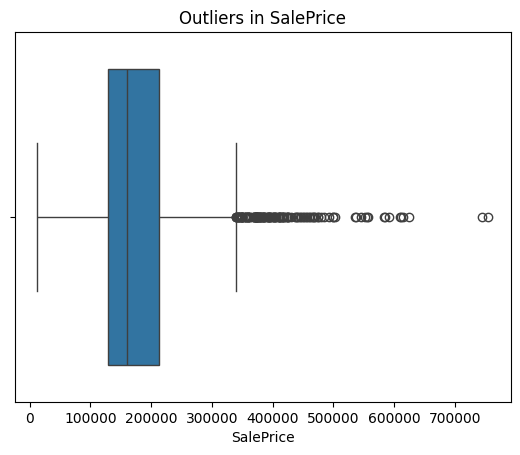

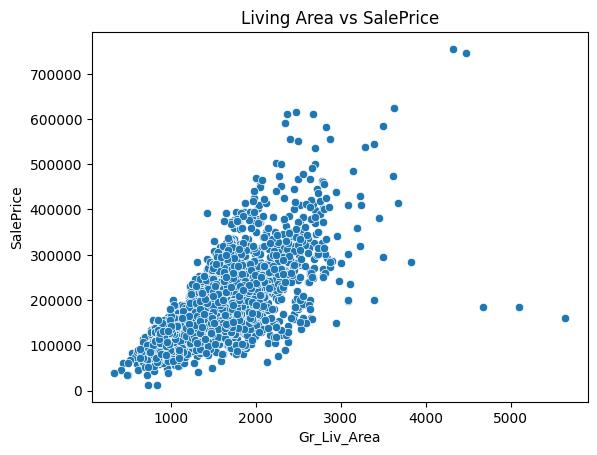

In [0]:
sns.boxplot(x=pdf["SalePrice"])
plt.title("Outliers in SalePrice")
plt.show()

sns.scatterplot(x=pdf["Gr_Liv_Area"], y=pdf["SalePrice"])
plt.title("Living Area vs SalePrice")
plt.show()


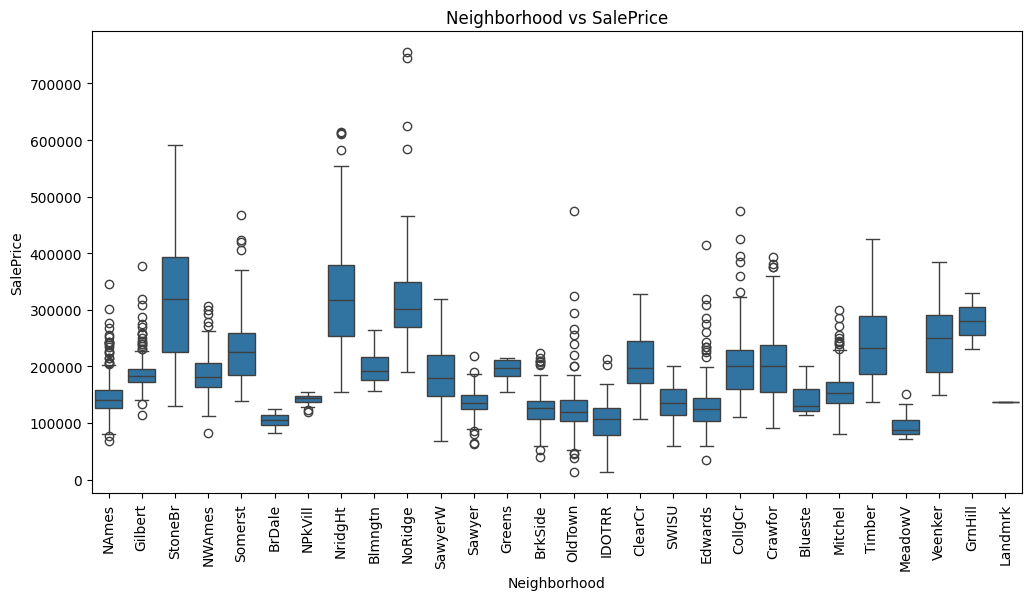

In [0]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Neighborhood", y="SalePrice", data=pdf)
plt.xticks(rotation=90)
plt.title("Neighborhood vs SalePrice")
plt.show()


In [0]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder


indexer = StringIndexer(inputCol="Neighborhood", outputCol="Neighborhood_index")
encoder = OneHotEncoder(inputCol="Neighborhood_index", outputCol="Neighborhood_vec")

df_indexed = indexer.fit(df_processed).transform(df_processed)
df_encoded = encoder.fit(df_indexed).transform(df_indexed)


In [0]:
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler, StandardScaler


for c in df_encoded.columns:
    df_encoded = df_encoded.withColumnRenamed(c, c.replace(" ", "_"))


df_encoded = df_encoded.withColumn("Age", col("Yr_Sold") - col("Year_Built"))


df_no_nulls = df_encoded.dropna(subset=["Gr_Liv_Area", "Garage_Area", "Total_Bsmt_SF", "Age"])


assembler = VectorAssembler(
    inputCols=["Gr_Liv_Area", "Garage_Area", "Total_Bsmt_SF", "Age"],
    outputCol="numerical_features",
    handleInvalid="skip"   
)

df_num = assembler.transform(df_no_nulls)


scaler = StandardScaler(inputCol="numerical_features", outputCol="numerical_scaled")
df_scaled = scaler.fit(df_num).transform(df_num)


display(df_scaled.select("Gr_Liv_Area", "Garage_Area", "Total_Bsmt_SF", "Age", "numerical_scaled").limit(5))


Gr_Liv_Area,Garage_Area,Total_Bsmt_SF,Age,numerical_scaled
1656,528,1080,50,"Map(vectorType -> dense, length -> 4, values -> List(3.275821781045079, 2.4552002719946944, 2.4507804895606853, 1.6509686853346566))"
896,730,882,49,"Map(vectorType -> dense, length -> 4, values -> List(1.7724253114833277, 3.3945003760532706, 2.0014707331412267, 1.6179493116279635))"
1329,312,1329,52,"Map(vectorType -> dense, length -> 4, values -> List(2.6289656684836413, 1.4508001607241374, 3.0158215468760656, 1.717007432748043))"
2110,522,2110,42,"Map(vectorType -> dense, length -> 4, values -> List(4.173903356283283, 2.4273002689038456, 4.788098919419487, 1.3868136956811115))"
1629,482,928,13,"Map(vectorType -> dense, length -> 4, values -> List(3.2224116433106484, 2.2413002482981867, 2.1058558280669595, 0.4292518581870107))"


In [0]:
features_path = f"abfss://features@{storage_account_name}.dfs.core.windows.net/AmesHousing_features"
df_scaled.write.format("parquet").mode("overwrite").save(features_path)


In [0]:
df_features = spark.read.parquet(features_path)
display(df_features.limit(5))


Order,PID,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,Condition_1,Condition_2,Bldg_Type,House_Style,Overall_Qual,Overall_Cond,Year_Built,Year_Remod/Add,Roof_Style,Roof_Matl,Exterior_1st,Exterior_2nd,Mas_Vnr_Type,Mas_Vnr_Area,Exter_Qual,Exter_Cond,Foundation,Bsmt_Qual,Bsmt_Cond,Bsmt_Exposure,BsmtFin_Type_1,BsmtFin_SF_1,BsmtFin_Type_2,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,Heating,Heating_QC,Central_Air,Electrical,1st_Flr_SF,2nd_Flr_SF,Low_Qual_Fin_SF,Gr_Liv_Area,Bsmt_Full_Bath,Bsmt_Half_Bath,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,Kitchen_Qual,TotRms_AbvGrd,Functional,Fireplaces,Fireplace_Qu,Garage_Type,Garage_Yr_Blt,Garage_Finish,Garage_Cars,Garage_Area,Garage_Qual,Garage_Cond,Paved_Drive,Wood_Deck_SF,Open_Porch_SF,Enclosed_Porch,3Ssn_Porch,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice,Neighborhood_index,Neighborhood_vec,Age,numerical_features,numerical_scaled
1,526301100,20,RL,141,31770,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112,TA,TA,CBlock,TA,Gd,Gd,BLQ,639,Unf,0,441,1080,GasA,Fa,Y,SBrkr,1656,0,0,1656,1,0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960,Fin,2,528,TA,TA,P,210,62,0,0,0,0,NA,NA,NA,0,5,2010,WD,Normal,215000,0.0,"Map(vectorType -> sparse, length -> 27, indices -> List(0), values -> List(1.0))",50,"Map(vectorType -> dense, length -> 4, values -> List(1656.0, 528.0, 1080.0, 50.0))","Map(vectorType -> dense, length -> 4, values -> List(3.275821781045079, 2.4552002719946944, 2.4507804895606853, 1.6509686853346566))"
2,526350040,20,RH,80,11622,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0,TA,TA,CBlock,TA,TA,No,Rec,468,LwQ,144,270,882,GasA,TA,Y,SBrkr,896,0,0,896,0,0,1,0,2,1,TA,5,Typ,0,NA,Attchd,1961,Unf,1,730,TA,TA,Y,140,0,0,0,120,0,NA,MnPrv,NA,0,6,2010,WD,Normal,105000,0.0,"Map(vectorType -> sparse, length -> 27, indices -> List(0), values -> List(1.0))",49,"Map(vectorType -> dense, length -> 4, values -> List(896.0, 730.0, 882.0, 49.0))","Map(vectorType -> dense, length -> 4, values -> List(1.7724253114833277, 3.3945003760532706, 2.0014707331412267, 1.6179493116279635))"
3,526351010,20,RL,81,14267,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108,TA,TA,CBlock,TA,TA,No,ALQ,923,Unf,0,406,1329,GasA,TA,Y,SBrkr,1329,0,0,1329,0,0,1,1,3,1,Gd,6,Typ,0,NA,Attchd,1958,Unf,1,312,TA,TA,Y,393,36,0,0,0,0,NA,NA,Gar2,12500,6,2010,WD,Normal,172000,0.0,"Map(vectorType -> sparse, length -> 27, indices -> List(0), values -> List(1.0))",52,"Map(vectorType -> dense, length -> 4, values -> List(1329.0, 312.0, 1329.0, 52.0))","Map(vectorType -> dense, length -> 4, values -> List(2.6289656684836413, 1.4508001607241374, 3.0158215468760656, 1.717007432748043))"
4,526353030,20,RL,93,11160,Pave,NA,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,None,0,Gd,TA,CBlock,TA,TA,No,ALQ,1065,Unf,0,1045,2110,GasA,Ex,Y,SBrkr,2110,0,0,2110,1,0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968,Fin,2,522,TA,TA,Y,0,0,0,0,0,0,NA,NA,NA,0,4,2010,WD,Normal,244000,0.0,"Map(vectorType -> sparse, length -> 27, indices -> List(0), values -> List(1.0))",42,"Map(vectorType -> dense, length -> 4, values -> List(2110.0, 522.0, 2110.0, 42.0))","Map(vectorType -> dense, length -> 4, values -> List(4.173903356283283, 2.4273002689038456, 4.788098919419487, 1.3868136956811115))"
5,527105010,60,RL,74,13830,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0,TA,TA,PConc,Gd,TA,No,GLQ,791,Unf,0,137,928,GasA,Gd,Y,SBrkr,928,701,0,1629,0,0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997,Fin,2,482,TA,TA,Y,212,34,0,0,0,0,NA,MnPrv,NA,0,3,2010,WD,Normal,189900,6.0,"Map(vectorType -> sparse, length -> 27, indices -> List(6), values -> List(1.0))",13,"Map(vectorType -> dense,

In [0]:
%sql
CREATE SCHEMA IF NOT EXISTS hive_metastore.ames_schema;


In [0]:
features_path = f"abfss://features@{storage_account_name}.dfs.core.windows.net/AmesHousing_features"

spark.sql(f"""
CREATE TABLE hive_metastore.ames_schema.ames_features
USING PARQUET
LOCATION '{features_path}'
""")


DataFrame[]

In [0]:
%sql
SHOW TABLES IN hive_metastore.ames_schema;

SELECT * FROM hive_metastore.ames_schema.ames_features LIMIT 10;


Order,PID,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,Condition_1,Condition_2,Bldg_Type,House_Style,Overall_Qual,Overall_Cond,Year_Built,Year_Remod/Add,Roof_Style,Roof_Matl,Exterior_1st,Exterior_2nd,Mas_Vnr_Type,Mas_Vnr_Area,Exter_Qual,Exter_Cond,Foundation,Bsmt_Qual,Bsmt_Cond,Bsmt_Exposure,BsmtFin_Type_1,BsmtFin_SF_1,BsmtFin_Type_2,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,Heating,Heating_QC,Central_Air,Electrical,1st_Flr_SF,2nd_Flr_SF,Low_Qual_Fin_SF,Gr_Liv_Area,Bsmt_Full_Bath,Bsmt_Half_Bath,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,Kitchen_Qual,TotRms_AbvGrd,Functional,Fireplaces,Fireplace_Qu,Garage_Type,Garage_Yr_Blt,Garage_Finish,Garage_Cars,Garage_Area,Garage_Qual,Garage_Cond,Paved_Drive,Wood_Deck_SF,Open_Porch_SF,Enclosed_Porch,3Ssn_Porch,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice,Neighborhood_index,Neighborhood_vec,Age,numerical_features,numerical_scaled
1,526301100,20,RL,141,31770,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112,TA,TA,CBlock,TA,Gd,Gd,BLQ,639,Unf,0,441,1080,GasA,Fa,Y,SBrkr,1656,0,0,1656,1,0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960,Fin,2,528,TA,TA,P,210,62,0,0,0,0,NA,NA,NA,0,5,2010,WD,Normal,215000,0.0,"Map(vectorType -> sparse, length -> 27, indices -> List(0), values -> List(1.0))",50,"Map(vectorType -> dense, length -> 4, values -> List(1656.0, 528.0, 1080.0, 50.0))","Map(vectorType -> dense, length -> 4, values -> List(3.275821781045079, 2.4552002719946944, 2.4507804895606853, 1.6509686853346566))"
2,526350040,20,RH,80,11622,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0,TA,TA,CBlock,TA,TA,No,Rec,468,LwQ,144,270,882,GasA,TA,Y,SBrkr,896,0,0,896,0,0,1,0,2,1,TA,5,Typ,0,NA,Attchd,1961,Unf,1,730,TA,TA,Y,140,0,0,0,120,0,NA,MnPrv,NA,0,6,2010,WD,Normal,105000,0.0,"Map(vectorType -> sparse, length -> 27, indices -> List(0), values -> List(1.0))",49,"Map(vectorType -> dense, length -> 4, values -> List(896.0, 730.0, 882.0, 49.0))","Map(vectorType -> dense, length -> 4, values -> List(1.7724253114833277, 3.3945003760532706, 2.0014707331412267, 1.6179493116279635))"
3,526351010,20,RL,81,14267,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108,TA,TA,CBlock,TA,TA,No,ALQ,923,Unf,0,406,1329,GasA,TA,Y,SBrkr,1329,0,0,1329,0,0,1,1,3,1,Gd,6,Typ,0,NA,Attchd,1958,Unf,1,312,TA,TA,Y,393,36,0,0,0,0,NA,NA,Gar2,12500,6,2010,WD,Normal,172000,0.0,"Map(vectorType -> sparse, length -> 27, indices -> List(0), values -> List(1.0))",52,"Map(vectorType -> dense, length -> 4, values -> List(1329.0, 312.0, 1329.0, 52.0))","Map(vectorType -> dense, length -> 4, values -> List(2.6289656684836413, 1.4508001607241374, 3.0158215468760656, 1.717007432748043))"
4,526353030,20,RL,93,11160,Pave,NA,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,None,0,Gd,TA,CBlock,TA,TA,No,ALQ,1065,Unf,0,1045,2110,GasA,Ex,Y,SBrkr,2110,0,0,2110,1,0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968,Fin,2,522,TA,TA,Y,0,0,0,0,0,0,NA,NA,NA,0,4,2010,WD,Normal,244000,0.0,"Map(vectorType -> sparse, length -> 27, indices -> List(0), values -> List(1.0))",42,"Map(vectorType -> dense, length -> 4, values -> List(2110.0, 522.0, 2110.0, 42.0))","Map(vectorType -> dense, length -> 4, values -> List(4.173903356283283, 2.4273002689038456, 4.788098919419487, 1.3868136956811115))"
5,527105010,60,RL,74,13830,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0,TA,TA,PConc,Gd,TA,No,GLQ,791,Unf,0,137,928,GasA,Gd,Y,SBrkr,928,701,0,1629,0,0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997,Fin,2,482,TA,TA,Y,212,34,0,0,0,0,NA,MnPrv,NA,0,3,2010,WD,Normal,189900,6.0,"Map(vectorType -> sparse, length -> 27, indices -> List(6), values -> List(1.0))",13,"Map(vectorType -> dense,

In [0]:
%sql
COMMENT ON TABLE hive_metastore.ames_schema.ames_features IS 'Engineered feature set for Ames Housing price prediction';
COMMENT ON COLUMN hive_metastore.ames_schema.ames_features.Age IS 'Age of property at time of sale';


In [0]:
%sql
SELECT * FROM hive_metastore.ames_schema.ames_features LIMIT 10;


Order,PID,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,Condition_1,Condition_2,Bldg_Type,House_Style,Overall_Qual,Overall_Cond,Year_Built,Year_Remod/Add,Roof_Style,Roof_Matl,Exterior_1st,Exterior_2nd,Mas_Vnr_Type,Mas_Vnr_Area,Exter_Qual,Exter_Cond,Foundation,Bsmt_Qual,Bsmt_Cond,Bsmt_Exposure,BsmtFin_Type_1,BsmtFin_SF_1,BsmtFin_Type_2,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,Heating,Heating_QC,Central_Air,Electrical,1st_Flr_SF,2nd_Flr_SF,Low_Qual_Fin_SF,Gr_Liv_Area,Bsmt_Full_Bath,Bsmt_Half_Bath,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,Kitchen_Qual,TotRms_AbvGrd,Functional,Fireplaces,Fireplace_Qu,Garage_Type,Garage_Yr_Blt,Garage_Finish,Garage_Cars,Garage_Area,Garage_Qual,Garage_Cond,Paved_Drive,Wood_Deck_SF,Open_Porch_SF,Enclosed_Porch,3Ssn_Porch,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice,Neighborhood_index,Neighborhood_vec,Age,numerical_features,numerical_scaled
1,526301100,20,RL,141,31770,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112,TA,TA,CBlock,TA,Gd,Gd,BLQ,639,Unf,0,441,1080,GasA,Fa,Y,SBrkr,1656,0,0,1656,1,0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960,Fin,2,528,TA,TA,P,210,62,0,0,0,0,NA,NA,NA,0,5,2010,WD,Normal,215000,0.0,"Map(vectorType -> sparse, length -> 27, indices -> List(0), values -> List(1.0))",50,"Map(vectorType -> dense, length -> 4, values -> List(1656.0, 528.0, 1080.0, 50.0))","Map(vectorType -> dense, length -> 4, values -> List(3.275821781045079, 2.4552002719946944, 2.4507804895606853, 1.6509686853346566))"
2,526350040,20,RH,80,11622,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0,TA,TA,CBlock,TA,TA,No,Rec,468,LwQ,144,270,882,GasA,TA,Y,SBrkr,896,0,0,896,0,0,1,0,2,1,TA,5,Typ,0,NA,Attchd,1961,Unf,1,730,TA,TA,Y,140,0,0,0,120,0,NA,MnPrv,NA,0,6,2010,WD,Normal,105000,0.0,"Map(vectorType -> sparse, length -> 27, indices -> List(0), values -> List(1.0))",49,"Map(vectorType -> dense, length -> 4, values -> List(896.0, 730.0, 882.0, 49.0))","Map(vectorType -> dense, length -> 4, values -> List(1.7724253114833277, 3.3945003760532706, 2.0014707331412267, 1.6179493116279635))"
3,526351010,20,RL,81,14267,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108,TA,TA,CBlock,TA,TA,No,ALQ,923,Unf,0,406,1329,GasA,TA,Y,SBrkr,1329,0,0,1329,0,0,1,1,3,1,Gd,6,Typ,0,NA,Attchd,1958,Unf,1,312,TA,TA,Y,393,36,0,0,0,0,NA,NA,Gar2,12500,6,2010,WD,Normal,172000,0.0,"Map(vectorType -> sparse, length -> 27, indices -> List(0), values -> List(1.0))",52,"Map(vectorType -> dense, length -> 4, values -> List(1329.0, 312.0, 1329.0, 52.0))","Map(vectorType -> dense, length -> 4, values -> List(2.6289656684836413, 1.4508001607241374, 3.0158215468760656, 1.717007432748043))"
4,526353030,20,RL,93,11160,Pave,NA,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,None,0,Gd,TA,CBlock,TA,TA,No,ALQ,1065,Unf,0,1045,2110,GasA,Ex,Y,SBrkr,2110,0,0,2110,1,0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968,Fin,2,522,TA,TA,Y,0,0,0,0,0,0,NA,NA,NA,0,4,2010,WD,Normal,244000,0.0,"Map(vectorType -> sparse, length -> 27, indices -> List(0), values -> List(1.0))",42,"Map(vectorType -> dense, length -> 4, values -> List(2110.0, 522.0, 2110.0, 42.0))","Map(vectorType -> dense, length -> 4, values -> List(4.173903356283283, 2.4273002689038456, 4.788098919419487, 1.3868136956811115))"
5,527105010,60,RL,74,13830,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0,TA,TA,PConc,Gd,TA,No,GLQ,791,Unf,0,137,928,GasA,Gd,Y,SBrkr,928,701,0,1629,0,0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997,Fin,2,482,TA,TA,Y,212,34,0,0,0,0,NA,MnPrv,NA,0,3,2010,WD,Normal,189900,6.0,"Map(vectorType -> sparse, length -> 27, indices -> List(6), values -> List(1.0))",13,"Map(vectorType -> dense,